In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import sunpy 
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import astropy
from astropy.io import fits, ascii
from astropy.visualization import ImageNormalize, AsinhStretch
import astropy.units as u
from sun_blinker import ImageBlinker, SunBlinker
import dkist
from fancy_colorbar import plot_colorbar
from sunkit_image import coalignment
from ndcube import NDCube
from astropy.wcs import WCS
import h5py 
import dask.array as da
from astropy.time import Time

In [2]:
dkist_fitv_tom_btot_map_shift = sunpy.map.Map("../../data/pid_1_123/BKEWK/dkist_fitv_tom_btot_map_shift.fits")
dkist_ftiv_tom_theta_map_shifted_masked = sunpy.map.Map("../../data/pid_1_123/BKEWK/dkist_fitv_tom_theta_map_shifted_masked.fits")
dkist_br_map = sunpy.map.Map(dkist_fitv_tom_btot_map_shift.data * np.cos(np.deg2rad(dkist_ftiv_tom_theta_map_shifted_masked.data)),
                             dkist_fitv_tom_btot_map_shift.meta)
dkist_br_map.plot_settings['aspect'] = dkist_br_map.scale.axis2/dkist_br_map.scale.axis1

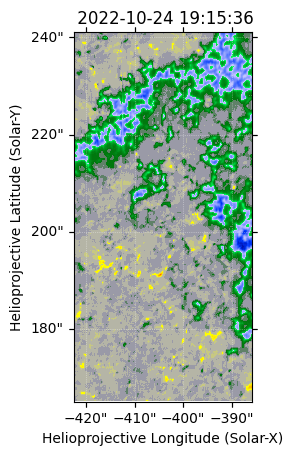

In [3]:
dkist_br_map.plot(cmap='hmimag',norm=ImageNormalize(vmin=-1500, vmax=1500))

In [7]:
hmi_supersynthia_file = "../../data/hmi/supersynthia/hmi.SuperSynthIA.20221024_191200_TAI.Br.fits"
with fits.open(hmi_supersynthia_file) as hdul:
    hmi_ss_data = hdul[1].data.copy()
    hmi_ss_header = hdul[0].header.copy()
hmi_ss_header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
CHECKSUM= 'GqaDGoY9GoaCGoW9'   / HDU checksum updated 2024-08-29T00:44:57       
DATASUM = '         0'         / data unit checksum updated 2024-08-29T00:44:57 

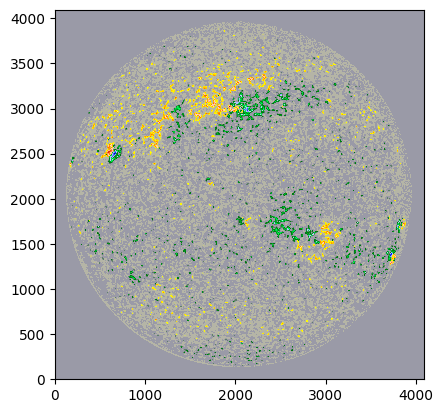

In [8]:
plt.imshow(hmi_ss_data, cmap='hmimag', norm=ImageNormalize(vmin=-1500, vmax=1500), origin='lower')

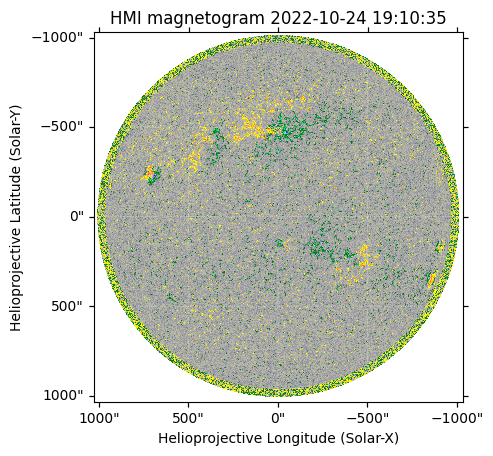

In [9]:
hmi_m_720s_map = sunpy.map.Map("../../data/hmi/supersynthia/hmi.M_720s.20221024_191200_TAI.3.magnetogram.fits")
hmi_m_720s_map.plot(cmap='hmimag',norm=ImageNormalize(vmin=-1500, vmax=1500))

In [11]:
ImageBlinker(hmi_ss_data[1300:1700, 2800:3200], hmi_m_720s_map.data[1300:1700, 2800:3200], 
             norm1=ImageNormalize(vmin=-100, vmax=100), norm2=ImageNormalize(vmin=-100, vmax=100),
             )

In [12]:
hmi_ss_map = sunpy.map.Map(hmi_ss_data, hmi_m_720s_map.wcs)

In [13]:
hmi_ss_map_rotated = hmi_ss_map.rotate()

In [23]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

file_Gband_pr = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Gband_AEZDV_pr.hdf5")
Gband_pr_set = file_Gband_pr["vbi_img"]
Gband_pr_da = da.from_array(Gband_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Gband_date_obs = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Gband_AEZDV_date_avg.txt")["DATE-AVG"])

dkist_vbi_target_header = fits.getheader("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((16,16))
dkist_vbi_target_cube_crop_rebin_4 = dkist_vbi_target_cube_crop.rebin((4,4))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [25]:
def repro_higherlevel_wcs(map, target_wcs, algorithm="adaptive"):
    cube = NDCube(map.data, map.wcs)
    cube_repro = cube.reproject_to(target_wcs, algorithm=algorithm)

    return cube_repro

In [51]:
sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_br_warp_to_hmi.fits")

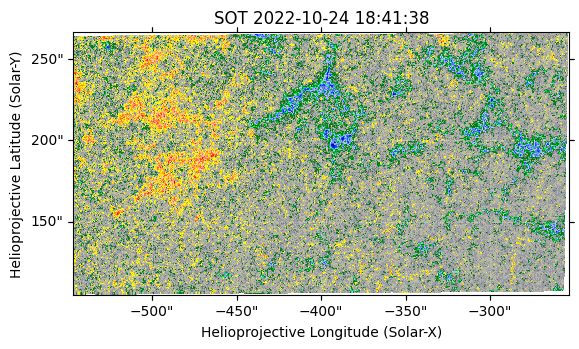

In [52]:
sotsp_br_map.plot(cmap='hmimag',norm=ImageNormalize(vmin=-1500, vmax=1500))

In [53]:
hrt_map = sunpy.map.Map("/cluster/home/zhuyin/Solar/extrapolate_schmidt64/data/phi_los_map_shifted_for_pore.fits")

In [67]:
with propagate_with_solar_surface():
    dkist_br_map_to_vbi = repro_higherlevel_wcs(dkist_br_map, dkist_vbi_target_cube_crop_rebin_4.wcs, algorithm="exact")
    hmi_ss_map_to_vbi = repro_higherlevel_wcs(hmi_ss_map, dkist_vbi_target_cube_crop_rebin.wcs, algorithm="exact")
    sotsp_br_map_to_vbi = repro_higherlevel_wcs(sotsp_br_map, dkist_vbi_target_cube_crop_rebin_4.wcs, algorithm="exact")
    hrt_map_to_vbi = repro_higherlevel_wcs(hrt_map, dkist_vbi_target_cube_crop_rebin.wcs, algorithm="exact")

/cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/reproject/common.py:142: UserWarning: The reproject_exact function currently has precision issues with images that have resolutions below ~0.05 arcsec, so the results may not be accurate.
  return reproject_func(


In [68]:
hrt_map_to_vbi.data.shape

(240, 240)

In [69]:
Hbeta_index = 98

vbi_hbeta_example = Hbeta_pr_da[Hbeta_index,:,:].compute()

gband_index = np.argmin(np.abs(Gband_date_obs - Hbeta_date_obs[Hbeta_index]))

vbi_gband_example = Gband_pr_da[gband_index,:,:].compute()

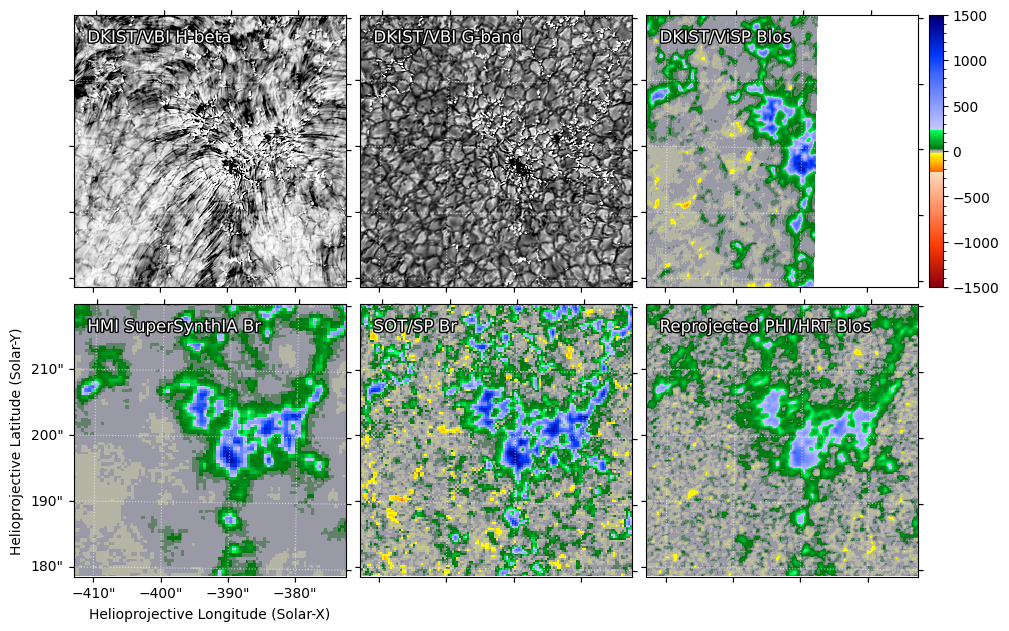

In [81]:
fig = plt.figure(figsize=(10,6.2),layout='constrained')

ax1 = fig.add_subplot(2,3,1,projection=dkist_vbi_target_cube_crop.wcs)
ax2 = fig.add_subplot(2,3,2,projection=dkist_vbi_target_cube_crop.wcs)
ax3 = fig.add_subplot(2,3,3,projection=dkist_vbi_target_cube_crop_rebin_4.wcs)
ax4 = fig.add_subplot(2,3,4,projection=dkist_vbi_target_cube_crop_rebin.wcs)
ax5 = fig.add_subplot(2,3,5,projection=dkist_vbi_target_cube_crop_rebin_4.wcs)
ax6 = fig.add_subplot(2,3,6,projection=dkist_vbi_target_cube_crop_rebin.wcs)

ax1.imshow(vbi_hbeta_example, cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1,
               stretch=AsinhStretch(0.6)),
               interpolation="none")

ax2.imshow(vbi_gband_example, cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1),
               interpolation="none")

im3 = ax3.imshow(dkist_br_map_to_vbi.data, cmap="hmimag",
           norm=ImageNormalize(vmin=-1500, vmax=1500),
           interpolation="none")

ax4.imshow(hmi_ss_map_to_vbi.data, cmap="hmimag",
           norm=ImageNormalize(vmin=-1500, vmax=1500),
           interpolation="none")

ax5.imshow(sotsp_br_map_to_vbi.data, cmap="hmimag",
           norm=ImageNormalize(vmin=-1500, vmax=1500),
           interpolation="none")

ax6.imshow(hrt_map_to_vbi.data, cmap="hmimag",
           norm=ImageNormalize(vmin=-1500, vmax=1500),
           interpolation="none")

# hmi_ss_map_to_vbi.plot(axes=ax4, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)
# sotsp_br_warp_map_to_vbi.plot(axes=ax5, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)
# hrt_blos_map_to_vbi.plot(axes=ax6, norm=ImageNormalize(vmin=-1500, vmax=1500), cmap='hmimag', title=None)

plot_colorbar(im3, ax3, bbox_to_anchor=[1.04,0,0.05,1], fontsize=10)

ax1.text(0.05, 0.95, 'DKIST/VBI H-beta', color='white',
            transform=ax1.transAxes, ha='left', va='top',
            path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
            fontsize=12)

ax2.text(0.05, 0.95, 'DKIST/VBI G-band', color='white',
            transform=ax2.transAxes, ha='left', va='top',
            path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
            fontsize=12)

ax3.text(0.05, 0.95, 'DKIST/ViSP Blos', color='white',
            transform=ax3.transAxes, ha='left', va='top',
            path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
            fontsize=12)

ax4.text(0.05, 0.95, 'HMI SuperSynthIA Br', color='white',
            transform=ax4.transAxes, ha='left', va='top',
            path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
            fontsize=12)

ax5.text(0.05, 0.95, 'SOT/SP Br', color='white',
            transform=ax5.transAxes, ha='left', va='top',
            path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
            fontsize=12)

ax6.text(0.05, 0.95, 'Reprojected PHI/HRT Blos', color='white',
            transform=ax6.transAxes, ha='left', va='top',
            path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()],
            fontsize=12)


for ax_ in (ax1,ax2,ax3,ax5,ax6):
    ax_.coords[0].axislabels.set_visible(False)
    ax_.coords[1].axislabels.set_visible(False)
    ax_.coords[0].set_ticklabel_visible(False)
    ax_.coords[1].set_ticklabel_visible(False)

for ax_ in (ax1,ax2,ax3,ax4,ax5,ax6):
    ax_.coords.grid(True,color="white",lw=0.8, alpha=0.6, ls=":")

ax4.set_xlabel("Helioprojective Longitude (Solar-X)")
ax4.set_ylabel("Helioprojective Latitude (Solar-Y)")

plt.savefig("../../figs/test_figs/dkist_all_magnetograms.png", dpi=300, bbox_inches='tight')

